# net_fish_sonar 

This is the code for getting the images and labels for solaqua fish dataset

## Image selection
The extraction and exporting (after they have been enhanced) of images happens in the solaqua_sonar_dataprocessing.ipynb. They are exported to their own folder ../data/exports/sonar/net_sonar/labelrady/images


We select the following bags: (200 imgs per)
- bag1:  2024-08-20_13-57-42 - Net is medium away. Oritentation varies. Some "folds" effect at the end. Some fish here and there. 
- bag2:  2024-08-20_17-02-00 - Net is close, far at the end. Stable data of the net. Few fishes on the inside. 
- bag3:  2024-08-20_13-55-34 - Net is far away, therefore weaker signal of net. Orientation varies a little. Few fish at the end. 
- bag4:  2024-08-20_14-31-29 - Net is far away. Few fish before the end. Net is a little wobbly. 
- bag5:  2024-08-20_14-38-37 - Net is medium away. Mostly stable data, very clear lines. Very few fishes on inside.
- bag6:  2024-08-20_14-34-07 - Net is medium-close away. Orientation constant. More unstable at the end. Very few fishes on inside.
- bag7:  2024-08-20_14-16-05 - Net is medium-close away. Unstable net - orientation and wobbles. Some fishes on inside.
- bag8:  2024-08-20_18-50-22 - Net is close. Stable. No fish inside.
- bag9:  2024-08-20_16-47-54 - Net is medium and cloase away. Unstable at times, inconsistent. Some fish inside.
- bag10: 2024-08-20_17-14-36 - Net is medium-close. Fish inside, ALOT at the end, difficult to understand net at the end. 


Naming convention:
- \<bagX>_<ts_ns>.png

In [1]:
from pathlib import Path
import zipfile

base_dir = Path.cwd()
zip_path = base_dir / "net_fish_sonar.zip"
extract_dir = base_dir / "processed"
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

print(f"Extracted {zip_path.name} into {extract_dir}")

Extracted net_fish_sonar.zip into /workspace/aquaculture-perception/data-processing/sonar/net_fish_sonar/processed


In [3]:
%pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 55.1 MB/s  0:00:00eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
# what do we have?
from pathlib import Path
from collections import Counter
import pandas as pd

# -----------------------------
# CONFIG
# -----------------------------
data_dir = Path.cwd() / "processed"
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

# -----------------------------
# HELPERS
# -----------------------------
def find_label_file(img_path: Path, root: Path):
    """
    Try to find the YOLO label file for an image.
    Supports common layouts like:
      processed/images/train/a.jpg  -> processed/labels/train/a.txt
      processed/train/images/a.jpg  -> processed/train/labels/a.txt
      processed/a.jpg               -> processed/a.txt
    """
    candidates = []

    # 1) same folder, same stem
    candidates.append(img_path.with_suffix(".txt"))

    # 2) replace any 'images' folder in path with 'labels'
    rel = img_path.relative_to(root)
    parts = list(rel.parts)
    for i, part in enumerate(parts):
        if part.lower() == "images":
            new_parts = parts.copy()
            new_parts[i] = "labels"
            candidates.append((root / Path(*new_parts)).with_suffix(".txt"))

    # remove duplicates while keeping order
    seen = set()
    deduped = []
    for c in candidates:
        if c not in seen:
            seen.add(c)
            deduped.append(c)

    for c in deduped:
        if c.exists():
            return c

    return None


def count_instances_in_label(label_path: Path):
    """
    Count YOLO instances = number of non-empty lines.
    Also return per-class counts from the first token on each line.
    """
    if label_path is None or not label_path.exists():
        return 0, Counter()

    class_counts = Counter()
    instance_count = 0

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            instance_count += 1
            class_id = line.split()[0]
            class_counts[class_id] += 1

    return instance_count, class_counts


# -----------------------------
# COLLECT IMAGES
# -----------------------------
images = sorted([p for p in data_dir.rglob("*") if p.suffix.lower() in image_exts])

if not images:
    raise FileNotFoundError(f"No images found under {data_dir}")

rows = []
total_class_counts = Counter()
label_files_found = 0

for img_path in images:
    label_path = find_label_file(img_path, data_dir)
    has_label_file = label_path is not None

    if has_label_file:
        label_files_found += 1

    instance_count, class_counts = count_instances_in_label(label_path)
    total_class_counts.update(class_counts)

    is_background = instance_count == 0

    rows.append({
        "image_path": str(img_path.relative_to(data_dir)),
        "image_name": img_path.name,
        "label_path": str(label_path.relative_to(data_dir)) if label_path else None,
        "has_label_file": has_label_file,
        "instances": instance_count,
        "is_background": is_background,
    })

df = pd.DataFrame(rows).sort_values(["instances", "image_name"], ascending=[False, True]).reset_index(drop=True)

# -----------------------------
# SUMMARY
# -----------------------------
total_images = len(df)
images_with_label_file = int(df["has_label_file"].sum())
images_with_instances = int((df["instances"] > 0).sum())
background_images = int(df["is_background"].sum())
total_instances = int(df["instances"].sum())

print("DATASET SUMMARY")
print("-" * 50)
print(f"Total images:                 {total_images}")
print(f"Images with label file:       {images_with_label_file}")
print(f"Images with >=1 instance:     {images_with_instances}")
print(f"Background images:            {background_images}")
print(f"Total annotation instances:   {total_instances}")

print("\nINSTANCES PER IMAGE")
print("-" * 50)
print(df[["image_name", "instances", "has_label_file", "is_background"]].to_string(index=False))

print("\nCLASS COUNTS (class_id -> instances)")
print("-" * 50)
if total_class_counts:
    for class_id, count in sorted(total_class_counts.items(), key=lambda x: int(x[0]) if str(x[0]).isdigit() else str(x[0])):
        print(f"{class_id}: {count}")
else:
    print("No labeled instances found.")

# Optional: save detailed report
report_path = data_dir / "dataset_report.csv"
df.to_csv(report_path, index=False)
print(f"\nSaved detailed report to: {report_path}")

DATASET SUMMARY
--------------------------------------------------
Total images:                 2000
Images with label file:       2000
Images with >=1 instance:     2000
Background images:            0
Total annotation instances:   2693

INSTANCES PER IMAGE
--------------------------------------------------
                   image_name  instances  has_label_file  is_background
bag10_1724166928180033900.jpg         13            True          False
bag10_1724166927149033000.jpg         12            True          False
bag10_1724166926700875100.jpg         11            True          False
bag10_1724166927411329800.jpg         11            True          False
bag10_1724166928428757800.jpg         11            True          False
bag10_1724166926438299900.jpg         10            True          False
bag10_1724166927659073800.jpg         10            True          False
bag10_1724166927916188200.jpg         10            True          False
bag10_1724166928683868100.jpg         10 

### make split

This code creates a bag-disjoint train/validation/test split for the fish-and-net YOLO dataset. All images from the same bag are kept in a single split to prevent leakage between training and evaluation data, since images from one bag are highly correlated. The code also tries to balance the splits with respect to the total number of images, background images, images containing fish or net, and the number of fish and net instances, before writing the final YOLO folder structure and dataset configuration files.

In [2]:
from pathlib import Path
import itertools
import math
import re
import shutil
from collections import defaultdict, Counter
import pandas as pd

# =========================================================
# CONFIG
# =========================================================
ROOT = Path.cwd() / "processed"
IMAGES_DIR = ROOT / "images"
LABELS_DIR = ROOT / "labels"
OUT_DIR = ROOT / "split_yolo_fish_net"

TARGET_RATIOS = {
    "train": 0.60,
    "val":   0.20,
    "test":  0.20,
}

MIN_BAGS = {
    "train": 4,
    "val": 2,
    "test": 2,
}

CLEAR_OUTPUT_DIR = True
WRITE_FILES = True

# YOLO class mapping
CLASS_ID_TO_NAME = {
    0: "fish",
    1: "net",
}

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

# Weights used in split optimization
METRIC_WEIGHTS = {
    "images": 1.0,
    "background_images": 1.0,
    "fish_images": 1.2,
    "net_images": 1.2,
    "fish_instances": 1.5,
    "net_instances": 1.5,
}

# =========================================================
# HELPERS
# =========================================================
def extract_bag_id(filename_stem: str) -> str:
    """
    Parse bag id from names like:
      bag1_1724166882647838100
      bag10_1724169387559191900
    """
    m = re.match(r"^(bag\d+)_", filename_stem)
    if not m:
        raise ValueError(f"Could not parse bag_id from filename stem: {filename_stem}")
    return m.group(1)


def get_label_path_for_image(img_path: Path) -> Path:
    """
    Supports:
      processed/images/foo.png -> processed/labels/foo.txt
    and mirrored subfolders if present.
    """
    rel = img_path.relative_to(IMAGES_DIR)

    candidate_1 = (LABELS_DIR / rel).with_suffix(".txt")
    if candidate_1.exists():
        return candidate_1

    candidate_2 = LABELS_DIR / f"{img_path.stem}.txt"
    return candidate_2


def read_yolo_label_counts(label_path: Path) -> Counter:
    """
    Returns Counter({class_id: count}) from a YOLO txt file.
    Missing or empty file -> empty Counter.
    """
    counts = Counter()

    if not label_path.exists():
        return counts

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            try:
                class_id = int(parts[0])
            except Exception:
                continue
            counts[class_id] += 1

    return counts


def choose_bag_counts(n_bags: int, ratios: dict, min_bags: dict) -> dict:
    n_test = max(min_bags["test"], round(ratios["test"] * n_bags))
    n_val = max(min_bags["val"], round(ratios["val"] * n_bags))
    n_train = n_bags - n_test - n_val

    while n_train < min_bags["train"]:
        excess_test = n_test - ratios["test"] * n_bags
        excess_val = n_val - ratios["val"] * n_bags

        if n_test > min_bags["test"] and excess_test >= excess_val:
            n_test -= 1
        elif n_val > min_bags["val"]:
            n_val -= 1
        else:
            raise ValueError(f"Not enough bags ({n_bags}) for requested split constraints.")
        n_train = n_bags - n_test - n_val

    return {"train": n_train, "val": n_val, "test": n_test}


def build_split_sums(split_bags: dict, bag_stats: dict) -> dict:
    out = {}
    for split, bags in split_bags.items():
        sums = defaultdict(float)
        for bag in bags:
            for metric, value in bag_stats[bag].items():
                sums[metric] += value
        out[split] = dict(sums)
    return out


def score_split(split_sums: dict, totals: dict, target_ratios: dict, metric_weights: dict) -> float:
    """
    Lower is better.
    """
    score = 0.0

    for metric, weight in metric_weights.items():
        total_metric = totals.get(metric, 0)
        if total_metric == 0:
            continue

        for split in ("train", "val", "test"):
            actual_ratio = split_sums[split].get(metric, 0) / total_metric
            target_ratio = target_ratios[split]
            score += weight * (actual_ratio - target_ratio) ** 2

    # Hard constraints: val/test should not be degenerate
    for split in ("val", "test"):
        if split_sums[split].get("images", 0) == 0:
            score += 1e6
        if split_sums[split].get("fish_images", 0) == 0:
            score += 1e6
        if split_sums[split].get("net_images", 0) == 0:
            score += 1e6

    return score


# =========================================================
# LOAD IMAGE + LABEL DATA
# =========================================================
image_paths = sorted(
    p for p in IMAGES_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
)

if not image_paths:
    raise FileNotFoundError(f"No images found in {IMAGES_DIR}")

records = []

for img_path in image_paths:
    bag_id = extract_bag_id(img_path.stem)
    label_path = get_label_path_for_image(img_path)

    class_counts = read_yolo_label_counts(label_path)

    fish_count = class_counts.get(0, 0)
    net_count = class_counts.get(1, 0)
    total_instances = sum(class_counts.values())

    records.append({
        "image_path": img_path,
        "label_path": label_path,
        "image_name": img_path.name,
        "bag_id": bag_id,
        "fish_instances": fish_count,
        "net_instances": net_count,
        "total_instances": total_instances,
        "fish_present": int(fish_count > 0),
        "net_present": int(net_count > 0),
        "background": int(total_instances == 0),
        "has_label_file": int(label_path.exists()),
    })

df = pd.DataFrame(records)

print("Loaded dataset")
print(f"  Images: {len(df)}")
print(f"  Bags:   {df['bag_id'].nunique()}")

# =========================================================
# BAG-LEVEL SUMMARY
# =========================================================
bag_summary = (
    df.groupby("bag_id")
      .agg(
          images=("image_name", "size"),
          background_images=("background", "sum"),
          fish_images=("fish_present", "sum"),
          net_images=("net_present", "sum"),
          fish_instances=("fish_instances", "sum"),
          net_instances=("net_instances", "sum"),
          total_instances=("total_instances", "sum"),
      )
      .reset_index()
      .sort_values("bag_id")
      .reset_index(drop=True)
)

bag_summary["background_rate"] = bag_summary["background_images"] / bag_summary["images"]
bag_summary["fish_image_rate"] = bag_summary["fish_images"] / bag_summary["images"]
bag_summary["net_image_rate"] = bag_summary["net_images"] / bag_summary["images"]

print("\nBag summary:")
display(bag_summary)

bag_ids = bag_summary["bag_id"].tolist()
n_bags = len(bag_ids)

bag_counts = choose_bag_counts(n_bags, TARGET_RATIOS, MIN_BAGS)
print("\nChosen number of bags per split:")
print(bag_counts)

bag_stats = (
    bag_summary.set_index("bag_id")[[
        "images",
        "background_images",
        "fish_images",
        "net_images",
        "fish_instances",
        "net_instances",
    ]]
    .to_dict(orient="index")
)

totals = {
    "images": int(bag_summary["images"].sum()),
    "background_images": int(bag_summary["background_images"].sum()),
    "fish_images": int(bag_summary["fish_images"].sum()),
    "net_images": int(bag_summary["net_images"].sum()),
    "fish_instances": int(bag_summary["fish_instances"].sum()),
    "net_instances": int(bag_summary["net_instances"].sum()),
}

# =========================================================
# EXHAUSTIVE SEARCH OVER BAG SPLITS
# =========================================================
best = None

all_bags = tuple(bag_ids)
n_test = bag_counts["test"]
n_val = bag_counts["val"]

for test_bags in itertools.combinations(all_bags, n_test):
    remaining_after_test = tuple(b for b in all_bags if b not in test_bags)

    for val_bags in itertools.combinations(remaining_after_test, n_val):
        train_bags = tuple(b for b in remaining_after_test if b not in val_bags)

        split_bags = {
            "train": train_bags,
            "val": val_bags,
            "test": test_bags,
        }

        split_sums = build_split_sums(split_bags, bag_stats)
        score = score_split(split_sums, totals, TARGET_RATIOS, METRIC_WEIGHTS)

        if best is None or score < best["score"]:
            best = {
                "score": score,
                "split_bags": split_bags,
                "split_sums": split_sums,
            }

if best is None:
    raise RuntimeError("Failed to find a valid bag split.")

bag_to_split = {}
for split, bags in best["split_bags"].items():
    for bag in bags:
        bag_to_split[bag] = split

print("\nBest bag assignment:")
for split in ("train", "val", "test"):
    print(f"  {split}: {list(best['split_bags'][split])}")

# =========================================================
# ASSIGN IMAGE-LEVEL SPLITS
# =========================================================
df["split"] = df["bag_id"].map(bag_to_split)

split_summary = (
    df.groupby("split")
      .agg(
          bags=("bag_id", lambda s: s.nunique()),
          images=("image_name", "size"),
          background_images=("background", "sum"),
          fish_images=("fish_present", "sum"),
          net_images=("net_present", "sum"),
          fish_instances=("fish_instances", "sum"),
          net_instances=("net_instances", "sum"),
          total_instances=("total_instances", "sum"),
      )
      .reindex(["train", "val", "test"])
      .reset_index()
)

split_summary["image_ratio"] = split_summary["images"] / len(df)
split_summary["background_rate"] = split_summary["background_images"] / split_summary["images"]
split_summary["fish_image_rate"] = split_summary["fish_images"] / split_summary["images"]
split_summary["net_image_rate"] = split_summary["net_images"] / split_summary["images"]

print("\nSplit summary:")
display(split_summary)

bag_assignment_df = bag_summary.copy()
bag_assignment_df["split"] = bag_assignment_df["bag_id"].map(bag_to_split)
bag_assignment_df = bag_assignment_df.sort_values(["split", "bag_id"]).reset_index(drop=True)

print("\nBag assignment table:")
display(bag_assignment_df)

# =========================================================
# WRITE YOLO SPLIT
# =========================================================
if WRITE_FILES:
    if CLEAR_OUTPUT_DIR and OUT_DIR.exists():
        shutil.rmtree(OUT_DIR)

    for split in ("train", "val", "test"):
        (OUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (OUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    for row in df.itertuples(index=False):
        split = row.split

        dst_img = OUT_DIR / "images" / split / row.image_name
        shutil.copy2(row.image_path, dst_img)

        dst_lbl = OUT_DIR / "labels" / split / f"{Path(row.image_name).stem}.txt"
        if Path(row.label_path).exists():
            shutil.copy2(row.label_path, dst_lbl)
        else:
            dst_lbl.write_text("", encoding="utf-8")

    save_df = df.copy()
    save_df["image_path"] = save_df["image_path"].astype(str)
    save_df["label_path"] = save_df["label_path"].astype(str)

    save_df.to_csv(OUT_DIR / "split_manifest.csv", index=False)
    bag_assignment_df.to_csv(OUT_DIR / "bag_assignment_summary.csv", index=False)
    split_summary.to_csv(OUT_DIR / "split_summary.csv", index=False)

    yaml_lines = [
        f"path: {OUT_DIR.as_posix()}",
        "train: images/train",
        "val: images/val",
        "test: images/test",
        "",
        "names:",
    ]
    for class_id, class_name in CLASS_ID_TO_NAME.items():
        yaml_lines.append(f"  {class_id}: {class_name}")

    (OUT_DIR / "dataset.yaml").write_text("\n".join(yaml_lines), encoding="utf-8")

    print(f"\nWrote split to: {OUT_DIR}")
    print(f"Dataset YAML:   {OUT_DIR / 'dataset.yaml'}")
    print(f"Manifest CSV:   {OUT_DIR / 'split_manifest.csv'}")
else:
    print("\nWRITE_FILES=False, so no files were copied.")

Loaded dataset
  Images: 2000
  Bags:   10

Bag summary:


,bag_id,images,background_images,fish_images,net_images,fish_instances,net_instances,total_instances,background_rate,fish_image_rate,net_image_rate
0,bag1,200,0,37,200,69,200,269,0.0,0.185,1.0
1,bag10,200,0,98,200,228,200,428,0.0,0.490,1.0
2,bag2,200,0,58,200,141,200,341,0.0,0.290,1.0
3,bag3,200,0,25,200,31,200,231,0.0,0.125,1.0
4,bag4,200,0,41,200,127,200,327,0.0,0.205,1.0
5,bag5,200,0,0,200,0,200,200,0.0,0.000,1.0
6,bag6,200,0,0,200,0,200,200,0.0,0.000,1.0
7,bag7,200,0,16,200,22,200,222,0.0,0.080,1.0
8,bag8,200,0,0,200,0,200,200,0.0,0.000,1.0
9,bag9,200,0,33,200,75,200,275,0.0,0.165,1.0



Chosen number of bags per split:
{'train': 6, 'val': 2, 'test': 2}

Best bag assignment:
  train: ['bag10', 'bag3', 'bag4', 'bag6', 'bag7', 'bag8']
  val: ['bag2', 'bag5']
  test: ['bag1', 'bag9']

Split summary:


,split,bags,images,background_images,fish_images,net_images,fish_instances,net_instances,total_instances,image_ratio,background_rate,fish_image_rate,net_image_rate
0,train,6,1200,0,180,1200,408,1200,1608,0.6,0.0,0.150,1.0
1,val,2,400,0,58,400,141,400,541,0.2,0.0,0.145,1.0
2,test,2,400,0,70,400,144,400,544,0.2,0.0,0.175,1.0



Bag assignment table:


,bag_id,images,background_images,fish_images,net_images,fish_instances,net_instances,total_instances,background_rate,fish_image_rate,net_image_rate,split
0,bag1,200,0,37,200,69,200,269,0.0,0.185,1.0,test
1,bag9,200,0,33,200,75,200,275,0.0,0.165,1.0,test
2,bag10,200,0,98,200,228,200,428,0.0,0.490,1.0,train
3,bag3,200,0,25,200,31,200,231,0.0,0.125,1.0,train
4,bag4,200,0,41,200,127,200,327,0.0,0.205,1.0,train
5,bag6,200,0,0,200,0,200,200,0.0,0.000,1.0,train
6,bag7,200,0,16,200,22,200,222,0.0,0.080,1.0,train
7,bag8,200,0,0,200,0,200,200,0.0,0.000,1.0,train
8,bag2,200,0,58,200,141,200,341,0.0,0.290,1.0,val
9,bag5,200,0,0,200,0,200,200,0.0,0.000,1.0,val



Wrote split to: /workspace/aquaculture-perception/data-processing/sonar/net_fish_sonar/processed/split_yolo_fish_net
Dataset YAML:   /workspace/aquaculture-perception/data-processing/sonar/net_fish_sonar/processed/split_yolo_fish_net/dataset.yaml
Manifest CSV:   /workspace/aquaculture-perception/data-processing/sonar/net_fish_sonar/processed/split_yolo_fish_net/split_manifest.csv


In [3]:
# Write yaml
from pathlib import Path


ROOT = Path.cwd()             

DATA = ROOT / "processed" 
IMAGES_TRAIN = DATA / "split_yolo_fish_net" / "images" / "train"
IMAGES_VAL = DATA / "split_yolo_fish_net" / "images" / "val"
IMAGES_TEST   = DATA / "split_yolo_fish_net" / "images" / "test"        # or use a dedicated val split if you have one

dataset_yaml = f"""
train: {IMAGES_TRAIN.as_posix()}
val:   {IMAGES_VAL.as_posix()}
test:  {IMAGES_TEST.as_posix()}

# RUOD has 10 classes
names:
  - fish
  - net
"""
(ROOT / "net_fish_sonar.yaml").write_text(dataset_yaml)
print("Wrote:", ROOT / "net_fish_sonar.yaml")


Wrote: /workspace/aquaculture-perception/data-processing/sonar/net_fish_sonar/net_fish_sonar.yaml


# Dataset summary

In [4]:
from pathlib import Path
import sys

DATA_PROCESSING_ROOT = Path.cwd().resolve().parents[1]  # your working solution
sys.path.insert(0, str(DATA_PROCESSING_ROOT))

from utils.yolo_dataset_summary import count_from_yaml

counts = count_from_yaml("net_fish_sonar.yaml")
# print(counts)
for split in ["train", "val", "test", "total"]:
    if split in counts:
        print(f"{split:5s}  images={counts[split]['images']:6d}  instances={counts[split]['instances']:8d}")


train  images=  1200  instances=    1608
val    images=   400  instances=     541
test   images=   400  instances=     544
total  images=  2000  instances=    2693


## Dataset examples

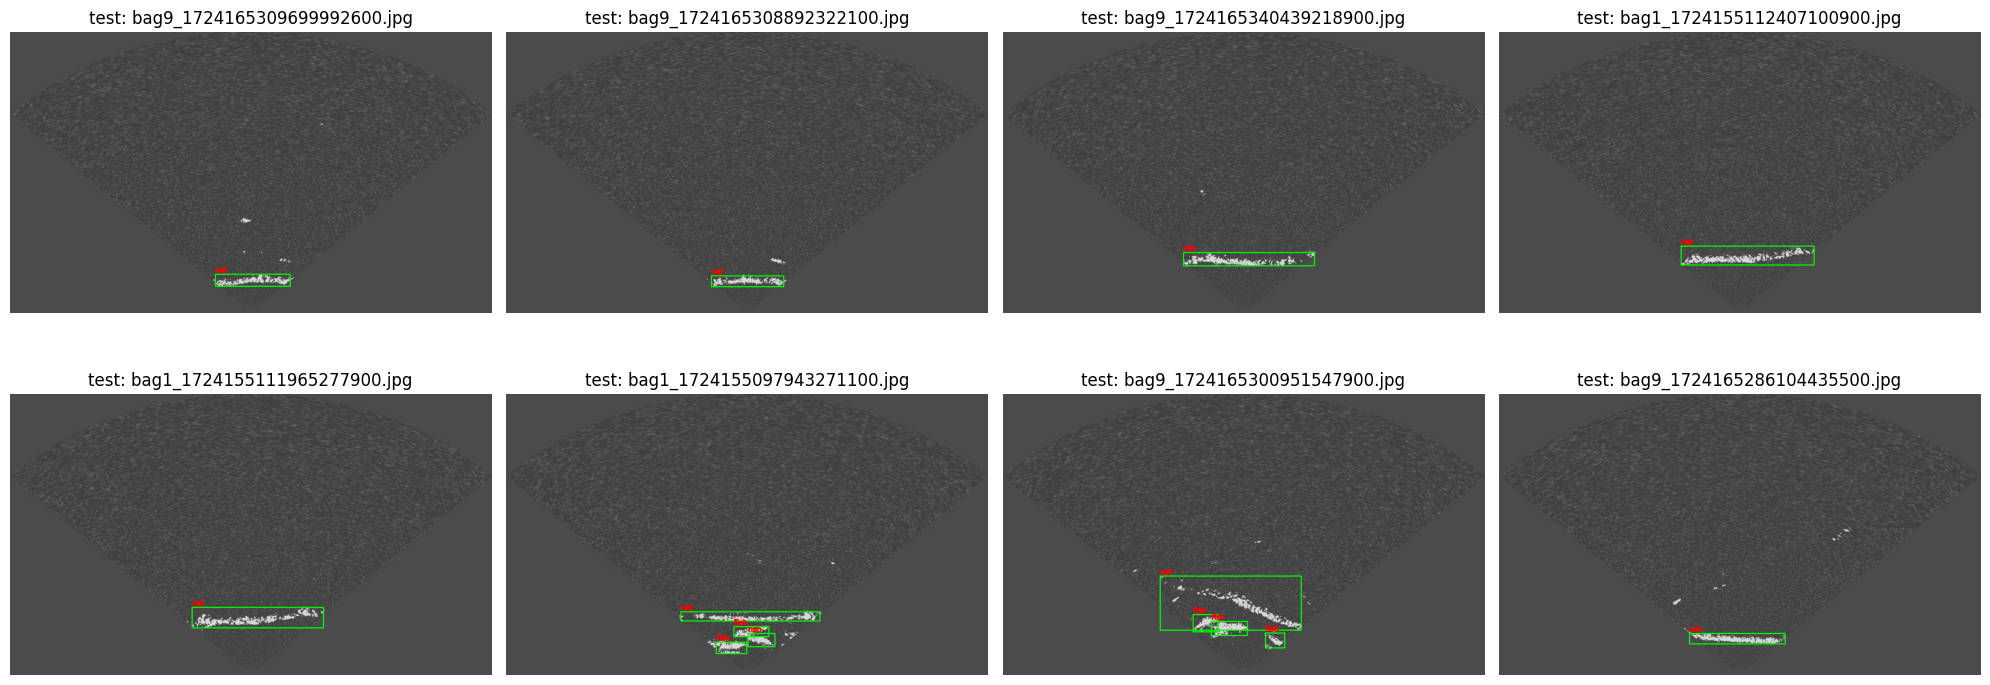

In [5]:
from pathlib import Path
import sys

DATA_PROCESSING_ROOT = Path.cwd().resolve().parents[1]  # RUOD -> vision -> data-processing
sys.path.insert(0, str(DATA_PROCESSING_ROOT))


from utils.yolo_viz import load_yolo_dataset_yaml, show_random_labeled_images

ds = load_yolo_dataset_yaml("net_fish_sonar.yaml")  # yaml is next to the notebook

split = "test"  # train / val / test
img_dir = {"train": ds.train, "val": ds.val, "test": ds.test}[split]

show_random_labeled_images(
    images_split_dir=img_dir,
    names=ds.names,
    num_pics=8,
    cols=4,
    require_labels=True,
    
    title_prefix=f"{split}: ",
)


# mmdetection setup

In [6]:
from pathlib import Path
import json

import yaml
from PIL import Image


IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def load_class_names(yaml_path: Path):
    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)

    names = data.get("names")
    if names is None:
        raise ValueError(f"No 'names' field found in {yaml_path}")

    if isinstance(names, dict):
        names = [names[k] for k in sorted(names.keys(), key=lambda x: int(x))]
    elif isinstance(names, list):
        names = list(names)
    else:
        raise ValueError(f"Unsupported 'names' format in {yaml_path}: {type(names)}")

    return names


def yolo_line_to_coco_bbox(parts, img_w, img_h):
    cls_id = int(float(parts[0]))
    x_c = float(parts[1]) * img_w
    y_c = float(parts[2]) * img_h
    bw = float(parts[3]) * img_w
    bh = float(parts[4]) * img_h

    x_min = x_c - bw / 2
    y_min = y_c - bh / 2

    x_min = max(0.0, min(x_min, img_w))
    y_min = max(0.0, min(y_min, img_h))
    bw = max(0.0, min(bw, img_w - x_min))
    bh = max(0.0, min(bh, img_h - y_min))

    return cls_id, [x_min, y_min, bw, bh]


def convert_split_to_coco(dataset_root: Path, split: str, class_names):
    image_dir = dataset_root / "images" / split
    label_dir = dataset_root / "labels" / split

    if not image_dir.exists():
        raise FileNotFoundError(f"Missing image dir: {image_dir}")
    if not label_dir.exists():
        raise FileNotFoundError(f"Missing label dir: {label_dir}")

    images = []
    annotations = []
    categories = [{"id": i + 1, "name": name} for i, name in enumerate(class_names)]

    ann_id = 1
    img_id = 1

    image_paths = sorted([p for p in image_dir.rglob("*") if p.suffix.lower() in IMG_EXTS])

    for img_path in image_paths:
        rel_img_path = img_path.relative_to(image_dir)
        label_path = label_dir / rel_img_path.with_suffix(".txt")

        with Image.open(img_path) as im:
            img_w, img_h = im.size

        images.append(
            {
                "id": img_id,
                "file_name": str(rel_img_path).replace("\\", "/"),
                "width": img_w,
                "height": img_h,
            }
        )

        if label_path.exists():
            with open(label_path, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue

                    parts = line.split()
                    if len(parts) < 5:
                        print(f"Skipping malformed line in {label_path}: {line}")
                        continue

                    cls_id, bbox = yolo_line_to_coco_bbox(parts[:5], img_w, img_h)
                    x, y, w, h = bbox

                    if w <= 0 or h <= 0:
                        continue

                    annotations.append(
                        {
                            "id": ann_id,
                            "image_id": img_id,
                            "category_id": cls_id + 1,
                            "bbox": [x, y, w, h],
                            "area": w * h,
                            "iscrowd": 0,
                            "segmentation": [],
                        }
                    )
                    ann_id += 1

        img_id += 1

    return {
        "images": images,
        "annotations": annotations,
        "categories": categories,
    }


def convert_yolo_to_coco_copy_only(
    dataset_root: Path,
    yaml_path: Path,
    splits=("train", "val", "test"),
    overwrite=False,
):
    class_names = load_class_names(yaml_path)
    out_dir = dataset_root / "annotations"
    out_dir.mkdir(parents=True, exist_ok=True)

    print("Reading YOLO data from:", dataset_root)
    print("Writing new COCO annotations to:", out_dir)
    print("Classes:", class_names)

    for split in splits:
        out_path = out_dir / f"{split}.json"

        if out_path.exists() and not overwrite:
            print(f"[{split}] skipped because {out_path} already exists")
            continue

        coco = convert_split_to_coco(dataset_root, split, class_names)

        with open(out_path, "w") as f:
            json.dump(coco, f)

        print(
            f"[{split}] wrote {out_path} | "
            f"{len(coco['images'])} images | "
            f"{len(coco['annotations'])} annotations"
        )

In [7]:
from pathlib import Path

ruod_root = Path.cwd()          # assuming notebook is in data-processing/vision/RUOD
dataset_root = ruod_root / "processed" / "split_yolo_fish_net"
yaml_path = ruod_root / "net_fish_sonar.yaml"

convert_yolo_to_coco_copy_only(
    dataset_root=dataset_root,
    yaml_path=yaml_path,
    splits=("train", "val", "test"),
    overwrite=False,   # safest mode
)

Reading YOLO data from: /workspace/aquaculture-perception/data-processing/sonar/net_fish_sonar/processed/split_yolo_fish_net
Writing new COCO annotations to: /workspace/aquaculture-perception/data-processing/sonar/net_fish_sonar/processed/split_yolo_fish_net/annotations
Classes: ['fish', 'net']
[train] wrote /workspace/aquaculture-perception/data-processing/sonar/net_fish_sonar/processed/split_yolo_fish_net/annotations/train.json | 1200 images | 1608 annotations
[val] wrote /workspace/aquaculture-perception/data-processing/sonar/net_fish_sonar/processed/split_yolo_fish_net/annotations/val.json | 400 images | 541 annotations
[test] wrote /workspace/aquaculture-perception/data-processing/sonar/net_fish_sonar/processed/split_yolo_fish_net/annotations/test.json | 400 images | 544 annotations


In [8]:
# confirm ok?
import json

for split in ["train", "val", "test"]:
    path = Path("processed") / "split_yolo_fish_net" / "annotations" / f"{split}.json"
    if path.exists():
        with open(path, "r") as f:
            data = json.load(f)
        print(
            split,
            "| images:", len(data["images"]),
            "| annotations:", len(data["annotations"]),
            "| classes:", [c["name"] for c in data["categories"]],
        )
    else:
        print(split, "| missing")

train | images: 1200 | annotations: 1608 | classes: ['fish', 'net']
val | images: 400 | annotations: 541 | classes: ['fish', 'net']
test | images: 400 | annotations: 544 | classes: ['fish', 'net']
